# ERA5 Heat Flux

In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

## Load Data

The data comes from here: https://cds.climate.copernicus.eu/datasets/reanalysis-era5-single-levels?tab=overview

In [2]:
# load data
df = xr.load_dataset("/albedo/home/maschr005/data/ERA5/ERA5_2011-2022_56-63S_0-16E_meanFluxes.grib", engine="cfgrib")

In [18]:
# print important attributes of all variables
for var in df.data_vars:
    print(f"Variable: {var}")
    print(f"  Long name: {df[var].attrs.get('long_name', 'N/A')}")
    print(f"  Mean: {df[var].mean().values:.1f}")
    print(f"  Units: {df[var].attrs.get('units', 'N/A')}")

Variable: avg_slhtf
  Long name: Time-mean surface latent heat flux
  Mean: -23.9
  Units: W m**-2
Variable: avg_snlwrf
  Long name: Time-mean surface net long-wave radiation flux
  Mean: -41.8
  Units: W m**-2
Variable: avg_snswrf
  Long name: Time-mean surface net short-wave radiation flux
  Mean: 83.0
  Units: W m**-2
Variable: avg_ishf
  Long name: Time-mean surface sensible heat flux
  Mean: -7.1
  Units: W m**-2


&rarr; Positive Heatflux = Downward

In [47]:
# count NaNs
nan_count = np.isnan(df["surface_net_heat_flux"].values).sum()
# total number of data points
N = np.prod(df["surface_net_heat_flux"].shape)
print(nan_count/N*100, "% of data points are NaN")

0.01710863986313088 % of data points are NaN


## Calculate Total Net Heat Flux

In [22]:
# calculate total net heat flux from heat flux components
df["surface_net_heat_flux"] = df["avg_slhtf"] + df["avg_snlwrf"] + df["avg_snswrf"] + df["avg_ishf"]  

In [23]:
# look at steps in [h]
df.step.values / (3600e9) # convert from nanoseconds to hours

array([ 3,  6,  9, 12], dtype='timedelta64[ns]')

## Total Dataset

In [24]:
print("Minimum net heat flux:", np.nanmin(df["surface_net_heat_flux"].values), df.surface_net_heat_flux.units)
print("Mean net heat flux:", np.nanmean(df["surface_net_heat_flux"].values), df.surface_net_heat_flux.units)
print("Maximum net heat flux:", np.nanmax(df["surface_net_heat_flux"].values), df.surface_net_heat_flux.units)

Minimum net heat flux: -1181.4575 W m**-2
Mean net heat flux: 10.164111 W m**-2
Maximum net heat flux: 879.39233 W m**-2


Text(0.5, 1.0, 'Histogram of surface net heat flux')

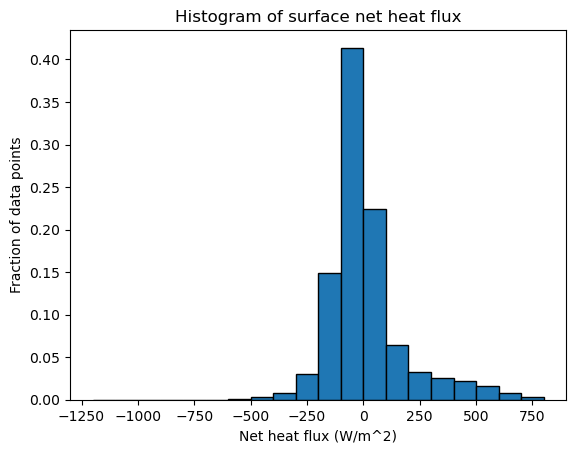

In [55]:
# historgram of net heat flux

# create bins
bins = np.arange(-1200, 900, 100)

# total number of data points
N = np.prod(df["surface_net_heat_flux"].shape)

plt.hist(df["surface_net_heat_flux"].values.flatten(), weights = np.ones(N) / N, bins=bins, edgecolor="black")

plt.xlabel("Net heat flux (W/m^2)")
plt.ylabel("Fraction of data points")
plt.title("Histogram of surface net heat flux")

# top 10% of net heat flux values

(0.0, 0.001)

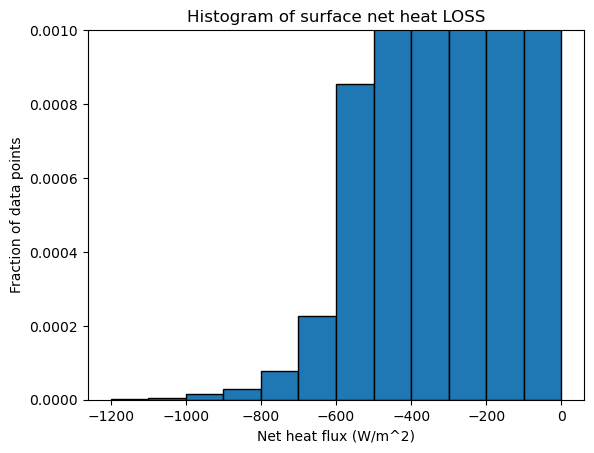

In [56]:
# historgram of net heat flux - zoom in on negative values

# create bins
bins = np.arange(-1200, 1, 100)

# total number of data points
N = np.prod(df["surface_net_heat_flux"].shape)

plt.hist(df["surface_net_heat_flux"].values.flatten(), weights = np.ones(N) / N, bins=bins, edgecolor="black")

plt.xlabel("Net heat flux (W/m^2)")
plt.ylabel("Fraction of data points")
plt.title("Histogram of surface net heat LOSS")
plt.ylim(0, 0.001)

# top 10% of net heat flux values

In [77]:
# calculate 1%, 0.1%, 0.01%, 0.001% percentiles of net heat flux
percentile_1 = np.nanpercentile(df["surface_net_heat_flux"].values, 1)
percentile_01 = np.nanpercentile(df["surface_net_heat_flux"].values, 0.1)
percentile_001 = np.nanpercentile(df["surface_net_heat_flux"].values, 0.01)
percentile_0001 = np.nanpercentile(df["surface_net_heat_flux"].values, 0.001)
print("1% percentile of net heat flux:", percentile_1, df.surface_net_heat_flux.units, "corresponds to", 0.01*365*24*3, "h/year")
print("0.1% percentile of net heat flux:", percentile_01, df.surface_net_heat_flux.units, "corresponds to", 0.001*365*24*3, "h/year")
print("0.01% percentile of net heat flux:", percentile_001, df.surface_net_heat_flux.units)
print("0.001% percentile of net heat flux:", percentile_0001, df.surface_net_heat_flux.units, "corresponds to", 0.0001*365*24*3, "h/year")

1% percentile of net heat flux: -312.11713 W m**-2 corresponds to 262.79999999999995 h/year
0.1% percentile of net heat flux: -515.2988 W m**-2 corresponds to 26.28 h/year
0.01% percentile of net heat flux: -727.03015 W m**-2
0.001% percentile of net heat flux: -971.7694 W m**-2 corresponds to 2.628 h/year


## Spatial Variability

In [70]:
# create a dataset with temporal statics of the net heat flux (mean, 90% percentile)
temporal_stats = xr.Dataset()
temporal_stats["mean_surface_net_heat_flux"] = df["surface_net_heat_flux"].mean(dim=["time", "step"])
temporal_stats["percentile_1_surface_net_heat_flux"] = df["surface_net_heat_flux"].quantile(0.01, dim=["time", "step"])


Text(0.5, 1.0, 'Mean surface net heat flux (W/m^2)')

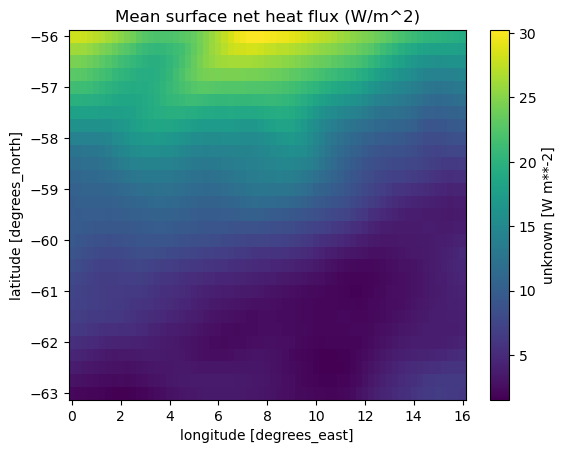

In [71]:
# plot mean net heat flux as a function of latitude and longitude
temporal_stats["mean_surface_net_heat_flux"].plot(x="longitude", y="latitude", cmap="viridis")
plt.title("Mean surface net heat flux (W/m^2)")

Text(0.5, 1.0, '1% percentile of surface net heat flux (W/m^2)')

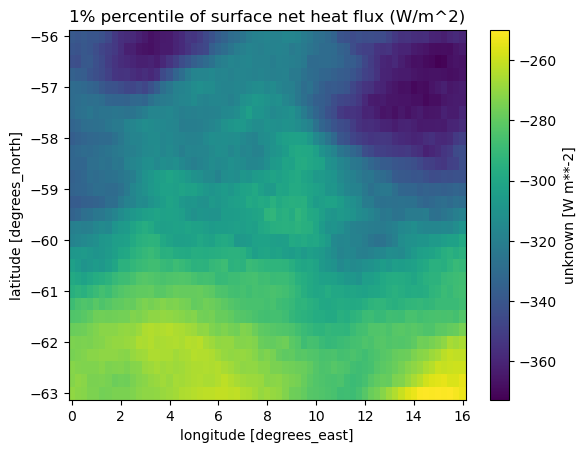

In [72]:
# plot 1 percentile as a funciton of lattitude and longitude
temporal_stats["percentile_1_surface_net_heat_flux"].plot(x="longitude", y="latitude", cmap="viridis")
plt.title("1% percentile of surface net heat flux (W/m^2)")

## Duration of Strong Heat Loss Events